In [4]:
import pandas as pd

X_train = pd.read_csv("X_train.csv") 
X_val   = pd.read_csv("X_val.csv")

y_train = pd.read_csv("y_train.csv").iloc[:, 0]
y_val   = pd.read_csv("y_val.csv").iloc[:, 0]


print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)
print(y_train.value_counts())


(73271, 44) (18318, 44) (73271,) (18318,)
readmitted
0    39484
1    25591
2     8196
Name: count, dtype: int64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

knn = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
pred = knn.predict(X_val)

print(classification_report(y_val, pred, digits=3))
print(confusion_matrix(y_val, pred))


              precision    recall  f1-score   support

           0      0.583     0.756     0.659      9871
           1      0.423     0.339     0.376      6398
           2      0.259     0.051     0.086      2049

    accuracy                          0.531     18318
   macro avg      0.422     0.382     0.373     18318
weighted avg      0.491     0.531     0.496     18318

[[7461 2280  130]
 [4061 2167  170]
 [1265  679  105]]


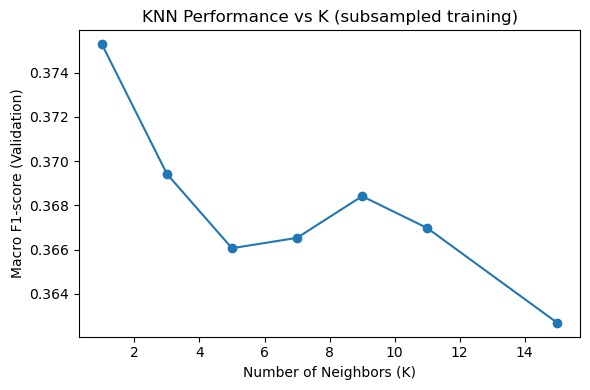

Best K = 1 Best Macro F1 = 0.3752766606181992


In [8]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=12000,
    random_state=42,
    stratify=y_train
)

K_list = [1, 3, 5, 7, 9, 11, 15]
macro_f1 = []

for k in K_list:
    model = Pipeline([
        ("preprocess", preprocess),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_sub, y_sub)
    pred_k = model.predict(X_val)
    macro_f1.append(f1_score(y_val, pred_k, average="macro"))

plt.figure(figsize=(6,4))
plt.plot(K_list, macro_f1, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Macro F1-score (Validation)")
plt.title("KNN Performance vs K (subsampled training)")
plt.tight_layout()
plt.show()

best_k = K_list[int(np.argmax(macro_f1))]
print("Best K =", best_k, "Best Macro F1 =", max(macro_f1))



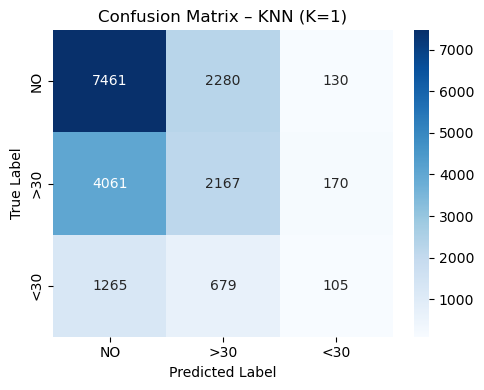

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_val, pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NO", ">30", "<30"],
    yticklabels=["NO", ">30", "<30"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – KNN (K=1)")
plt.tight_layout()
plt.show()
